In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import glob
import os
import datetime

import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import font_manager,rc
# 한글 폰트
font_location = "C:\Windows\Fonts\malgun.ttf"
font_name = font_manager.FontProperties(fname=font_location).get_name()
rc('font',family=font_name)
plt.rcParams['axes.unicode_minus'] = False  # 유니코드 마이너스 기호 사용

In [8]:
df = pd.read_csv("data/2024년도.csv", encoding="cp949")
print(df.columns)
print(f"[2024] 전체 행수(선택 컬럼 기준): {len(df):,}")

Index(['기준년도', '가입자일련번호', '시도코드', '성별코드', '연령대코드(5세단위)', '신장(5cm단위)',
       '체중(5kg단위)', '허리둘레', '시력(좌)', '시력(우)', '청력(좌)', '청력(우)', '수축기혈압',
       '이완기혈압', '식전혈당(공복혈당)', '총콜레스테롤', '트리글리세라이드', 'HDL콜레스테롤', 'LDL콜레스테롤',
       '혈색소', '요단백', '혈청크레아티닌', '혈청지오티(AST)', '혈청지피티(ALT)', '감마지티피', '흡연상태',
       '음주여부', '구강검진수검여부', '치아우식증유무', '결손치 유무', '치아마모증유무', '제3대구치(사랑니) 이상',
       '치석'],
      dtype='object')
[2024] 전체 행수(선택 컬럼 기준): 1,000,000


In [ ]:
def load_interval_data(start_year=2004, interval=3, threshold=100):
    today_year = datetime.datetime.today().year
    years_to_use = list(range(start_year, today_year+1, interval))
    print(f"자동 생성된 연도 리스트 ({interval}년 간격):", years_to_use)

    # 후보 컬럼명 리스트
    age_candidates = ["연령대코드(5세단위)", "연령대 코드(5세단위)"]
    glucose_candidates = ["식전혈당(공복혈당)", "식전혈당", "혈당"]

    file_list = glob.glob("data/*.csv") + glob.glob("data/*.CSV")
    df_list = []

    for file in file_list:
        year_str = os.path.basename(file).split("년")[0]
        if not year_str.isdigit():
            continue
        year = int(year_str)

        if year not in years_to_use:
            continue

        # 우선 파일 전체 열 이름 확인 (nrows=5만 읽어서 빠르게)
        try:
            df_check = pd.read_csv(file, encoding="cp949", low_memory=False, nrows=5)
        except UnicodeDecodeError:
            df_check = pd.read_csv(file, encoding="utf-8", low_memory=False, nrows=5)

        # 실제 존재하는 컬럼 찾기
        age_col = next((c for c in age_candidates if c in df_check.columns), None)
        glucose_col = next((c for c in glucose_candidates if c in df_check.columns), None)

        if not age_col or not glucose_col:
            print(f"⚠️ {file}에서 필요한 컬럼을 찾을 수 없음")
            print("→ 실제 컬럼들:", df_check.columns.tolist())
            continue

        # 필요한 컬럼만 다시 읽기
        try:
            df = pd.read_csv(file, encoding="cp949", usecols=[age_col, glucose_col], low_memory=False)
        except UnicodeDecodeError:
            df = pd.read_csv(file, encoding="utf-8", usecols=[age_col, glucose_col], low_memory=False)

        # 혈당 필터
        df = df[df[glucose_col] >= threshold]

        # 연도 구간별 연령대 필터
        if year <= 2013:  # 2010~2013 체계
            df_2340 = df[df[age_col].isin([1,2,3,4,5,6])]
            df_5670 = df[df[age_col].isin([7,8,9,10,11,12])]
        else:  # 2014년 이후 체계
            df_2340 = df[df[age_col].isin([5,6,7,8,9,10])]
            df_5670 = df[df[age_col].isin([11,12,13,14,15,16])]

        # 컬럼명 통일
        df_2340 = df_2340.rename(columns={age_col:"연령대코드", glucose_col:"식전혈당"}).assign(연도=year, 그룹="2340대")
        df_5670 = df_5670.rename(columns={age_col:"연령대코드", glucose_col:"식전혈당"}).assign(연도=year, 그룹="5670대")

        df_list.extend([df_2340, df_5670])

    return pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame()

# 실행 예시
# 2년 간격 데이터
df_interval_2 = load_interval_data(interval=2)

# 3년 간격 데이터
df_interval_3 = load_interval_data(interval=3)

print(df_interval_2.head())
print(df_interval_3.head())

In [50]:
print(df_interval_2.columns)
print(df_interval_3.columns)

Index(['연령대코드', '식전혈당', '연도', '그룹'], dtype='object')
Index(['연령대코드', '식전혈당', '연도', '그룹'], dtype='object')


In [51]:
print("2년 : ", df_interval_2.info)
print("3년 : ", df_interval_3.info)

2년 :  <bound method DataFrame.info of          연령대코드   식전혈당    연도    그룹
0            1  102.0  2004  230대
1            1  100.0  2004  230대
2            1  114.0  2004  230대
3            1  108.0  2004  230대
4            1  105.0  2004  230대
...        ...    ...   ...   ...
7230513     13  103.0  2024  450대
7230514     12  166.0  2024  450대
7230515     13  100.0  2024  450대
7230516     12  192.0  2024  450대
7230517     13  126.0  2024  450대

[7230518 rows x 4 columns]>
3년 :  <bound method DataFrame.info of          연령대코드   식전혈당    연도    그룹
0            1  102.0  2004  230대
1            1  100.0  2004  230대
2            1  114.0  2004  230대
3            1  108.0  2004  230대
4            1  105.0  2004  230대
...        ...    ...   ...   ...
4516537     14  149.0  2022  450대
4516538     14  163.0  2022  450대
4516539     15  134.0  2022  450대
4516540     12  181.0  2022  450대
4516541     14  173.0  2022  450대

[4516542 rows x 4 columns]>


In [52]:
print("2년 결측치 : ", df_interval_2.isnull().sum())
print("3년 결측치 : ", df_interval_3.isnull().sum())
print("2024년 데이터 수 : ", 

2년 결측치 :  연령대코드    0
식전혈당     0
연도       0
그룹       0
dtype: int64
3년 결측치 :  연령대코드    0
식전혈당     0
연도       0
그룹       0
dtype: int64


In [55]:
# 전체 데이터 (혈당 필터 X)
df_interval_2_all = load_interval_data(interval=2, threshold=0)
df_interval_3_all = load_interval_data(interval=3, threshold=0)

# 혈당 ≥ 100 데이터 (이미 있음)
df_interval_2_high = df_interval_2
df_interval_3_high = df_interval_3

# 비율 계산
ratio_2 = (df_interval_2_high.groupby(["연도","그룹"]).size() / 
           df_interval_2_all.groupby(["연도","그룹"]).size() * 100).unstack(fill_value=0)

ratio_3 = (df_interval_3_high.groupby(["연도","그룹"]).size() / 
           df_interval_3_all.groupby(["연도","그룹"]).size() * 100).unstack(fill_value=0)

print("=== 2년 간격 비율(%) ===")
print(ratio_2)

print("\n=== 3년 간격 비율(%) ===")
print(ratio_3)

자동 생성된 연도 리스트 (2년 간격): [2004, 2006, 2008, 2010, 2012, 2014, 2016, 2018, 2020, 2022, 2024]
자동 생성된 연도 리스트 (3년 간격): [2004, 2007, 2010, 2013, 2016, 2019, 2022, 2025]
=== 2년 간격 비율(%) ===
그룹         230대       450대
연도                        
2004  21.010465  36.038630
2006  20.783136  36.327996
2008  21.289583  38.016413
2010  22.741452  39.993252
2012  22.929600  40.693397
2014  25.176693  43.572262
2016  26.954123  45.808106
2018  29.189522  47.937042
2020  30.058176  51.301384
2022  28.263571  50.124693
2024  28.234377  50.207929

=== 3년 간격 비율(%) ===
그룹         230대       450대
연도                        
2004  21.010465  36.038630
2007  21.747353  38.168346
2010  22.741452  39.993252
2013  23.808144  42.303787
2016  26.954123  45.808106
2019  28.650343  49.010676
2022  28.263571  50.124693


In [40]:
for y in [2012, 2014, 2016]:
    print(y, df_interval_2[df_interval_2["연도"]==y]["연령대코드"].unique())
    print(y, df_interval_2[df_interval_2["연도"]==y]["연령대코드"].max())
    print(y, df_interval_2[df_interval_2["연도"]==y].info)

2012 [1 2 3 4 5 6 7 8]
2012 8
2012 <bound method DataFrame.info of          연령대코드   식전혈당    연도    그룹
814479       1  101.0  2012  230대
814480       1  104.0  2012  230대
814481       1  100.0  2012  230대
814482       1  101.0  2012  230대
814483       1  113.0  2012  230대
...        ...    ...   ...   ...
3520896      8  103.0  2012  450대
3520897      8  118.0  2012  450대
3520898      8  112.0  2012  450대
3520899      8  179.0  2012  450대
3520900      8  116.0  2012  450대

[430344 rows x 4 columns]>
2014 [ 6  5  7  8 12 11  9 10]
2014 12
2014 <bound method DataFrame.info of          연령대코드   식전혈당    연도    그룹
1029651      6  110.0  2014  230대
1029652      5  124.0  2014  230대
1029653      6  226.0  2014  230대
1029654      6  103.0  2014  230대
1029655      6  104.0  2014  230대
...        ...    ...   ...   ...
3752080     12  102.0  2014  450대
3752081     10  100.0  2014  450대
3752082     10  102.0  2014  450대
3752083     10  105.0  2014  450대
3752084     11  112.0  2014  450대

[462368 rows

In [56]:
# 연도별 그룹 비율 추출 함수
def group_ratios(ratio_df):
    """
    ratio_df: unstack()된 비율 DataFrame (연도 index, 그룹 columns)
    """
    counts_230 = ratio_df["2340대"] if "2340대" in ratio_df.columns else ratio_df["230대"]
    counts_450 = ratio_df["5670대"] if "5670대" in ratio_df.columns else ratio_df["450대"]
    return counts_230, counts_450


# 2년 간격 비율 데이터
counts_230_2, counts_450_2 = group_ratios(ratio_2)

# 3년 간격 비율 데이터
counts_230_3, counts_450_3 = group_ratios(ratio_3)

print("2년 간격 2340대 비율:\n", counts_230_2)
print("2년 간격 5670대 비율:\n", counts_450_2)

2년 간격 2340대 비율:
 연도
2004    21.010465
2006    20.783136
2008    21.289583
2010    22.741452
2012    22.929600
2014    25.176693
2016    26.954123
2018    29.189522
2020    30.058176
2022    28.263571
2024    28.234377
Name: 230대, dtype: float64
2년 간격 5670대 비율:
 연도
2004    36.038630
2006    36.327996
2008    38.016413
2010    39.993252
2012    40.693397
2014    43.572262
2016    45.808106
2018    47.937042
2020    51.301384
2022    50.124693
2024    50.207929
Name: 450대, dtype: float64


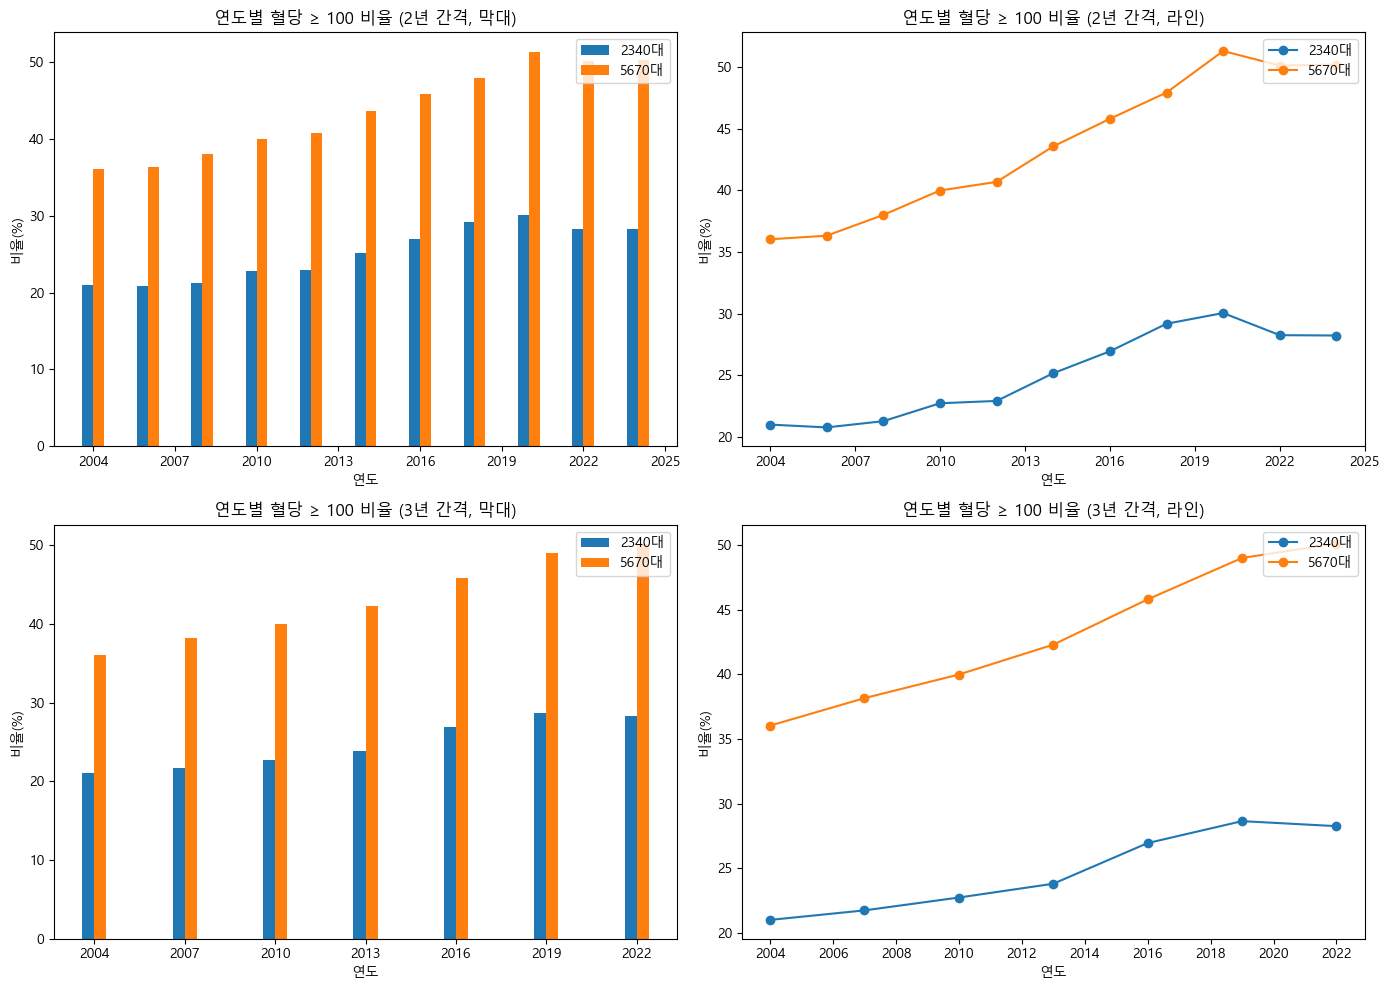

In [57]:
import matplotlib.ticker as mticker

# 2년 간격 비율 데이터에서 그룹별 시리즈 추출
ratio_230_2 = ratio_2["2340대"] if "2340대" in ratio_2.columns else ratio_2["230대"]
ratio_450_2 = ratio_2["5670대"] if "5670대" in ratio_2.columns else ratio_2["450대"]

# 3년 간격 비율 데이터에서 그룹별 시리즈 추출
ratio_230_3 = ratio_3["2340대"] if "2340대" in ratio_3.columns else ratio_3["230대"]
ratio_450_3 = ratio_3["5670대"] if "5670대" in ratio_3.columns else ratio_3["450대"]

# subplot 만들기 (2행 2열)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# === 2년 막대 ===
axes[0,0].bar(ratio_230_2.index-0.2, ratio_230_2.values, width=0.4, label="2340대")
axes[0,0].bar(ratio_450_2.index+0.2, ratio_450_2.values, width=0.4, label="5670대")
axes[0,0].set_title("연도별 혈당 ≥ 100 비율 (2년 간격, 막대)")
axes[0,0].set_xlabel("연도"); axes[0,0].set_ylabel("비율(%)")
axes[0,0].legend(loc="upper right")
axes[0,0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))  # x축 정수

# === 2년 라인 ===
axes[0,1].plot(ratio_230_2.index, ratio_230_2.values, marker="o", label="2340대")
axes[0,1].plot(ratio_450_2.index, ratio_450_2.values, marker="o", label="5670대")
axes[0,1].set_title("연도별 혈당 ≥ 100 비율 (2년 간격, 라인)")
axes[0,1].set_xlabel("연도"); axes[0,1].set_ylabel("비율(%)")
axes[0,1].legend(loc="upper right")
axes[0,1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# === 3년 막대 ===
axes[1,0].bar(ratio_230_3.index-0.2, ratio_230_3.values, width=0.4, label="2340대")
axes[1,0].bar(ratio_450_3.index+0.2, ratio_450_3.values, width=0.4, label="5670대")
axes[1,0].set_title("연도별 혈당 ≥ 100 비율 (3년 간격, 막대)")
axes[1,0].set_xlabel("연도"); axes[1,0].set_ylabel("비율(%)")
axes[1,0].legend(loc="upper right")
axes[1,0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# === 3년 라인 ===
axes[1,1].plot(ratio_230_3.index, ratio_230_3.values, marker="o", label="2340대")
axes[1,1].plot(ratio_450_3.index, ratio_450_3.values, marker="o", label="5670대")
axes[1,1].set_title("연도별 혈당 ≥ 100 비율 (3년 간격, 라인)")
axes[1,1].set_xlabel("연도"); axes[1,1].set_ylabel("비율(%)")
axes[1,1].legend(loc="upper right")
axes[1,1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()